## HI I GOT pissed on my google collab runtime credit over and i have decided to build my own yolov8 like i did built own yolov1

# Architecture

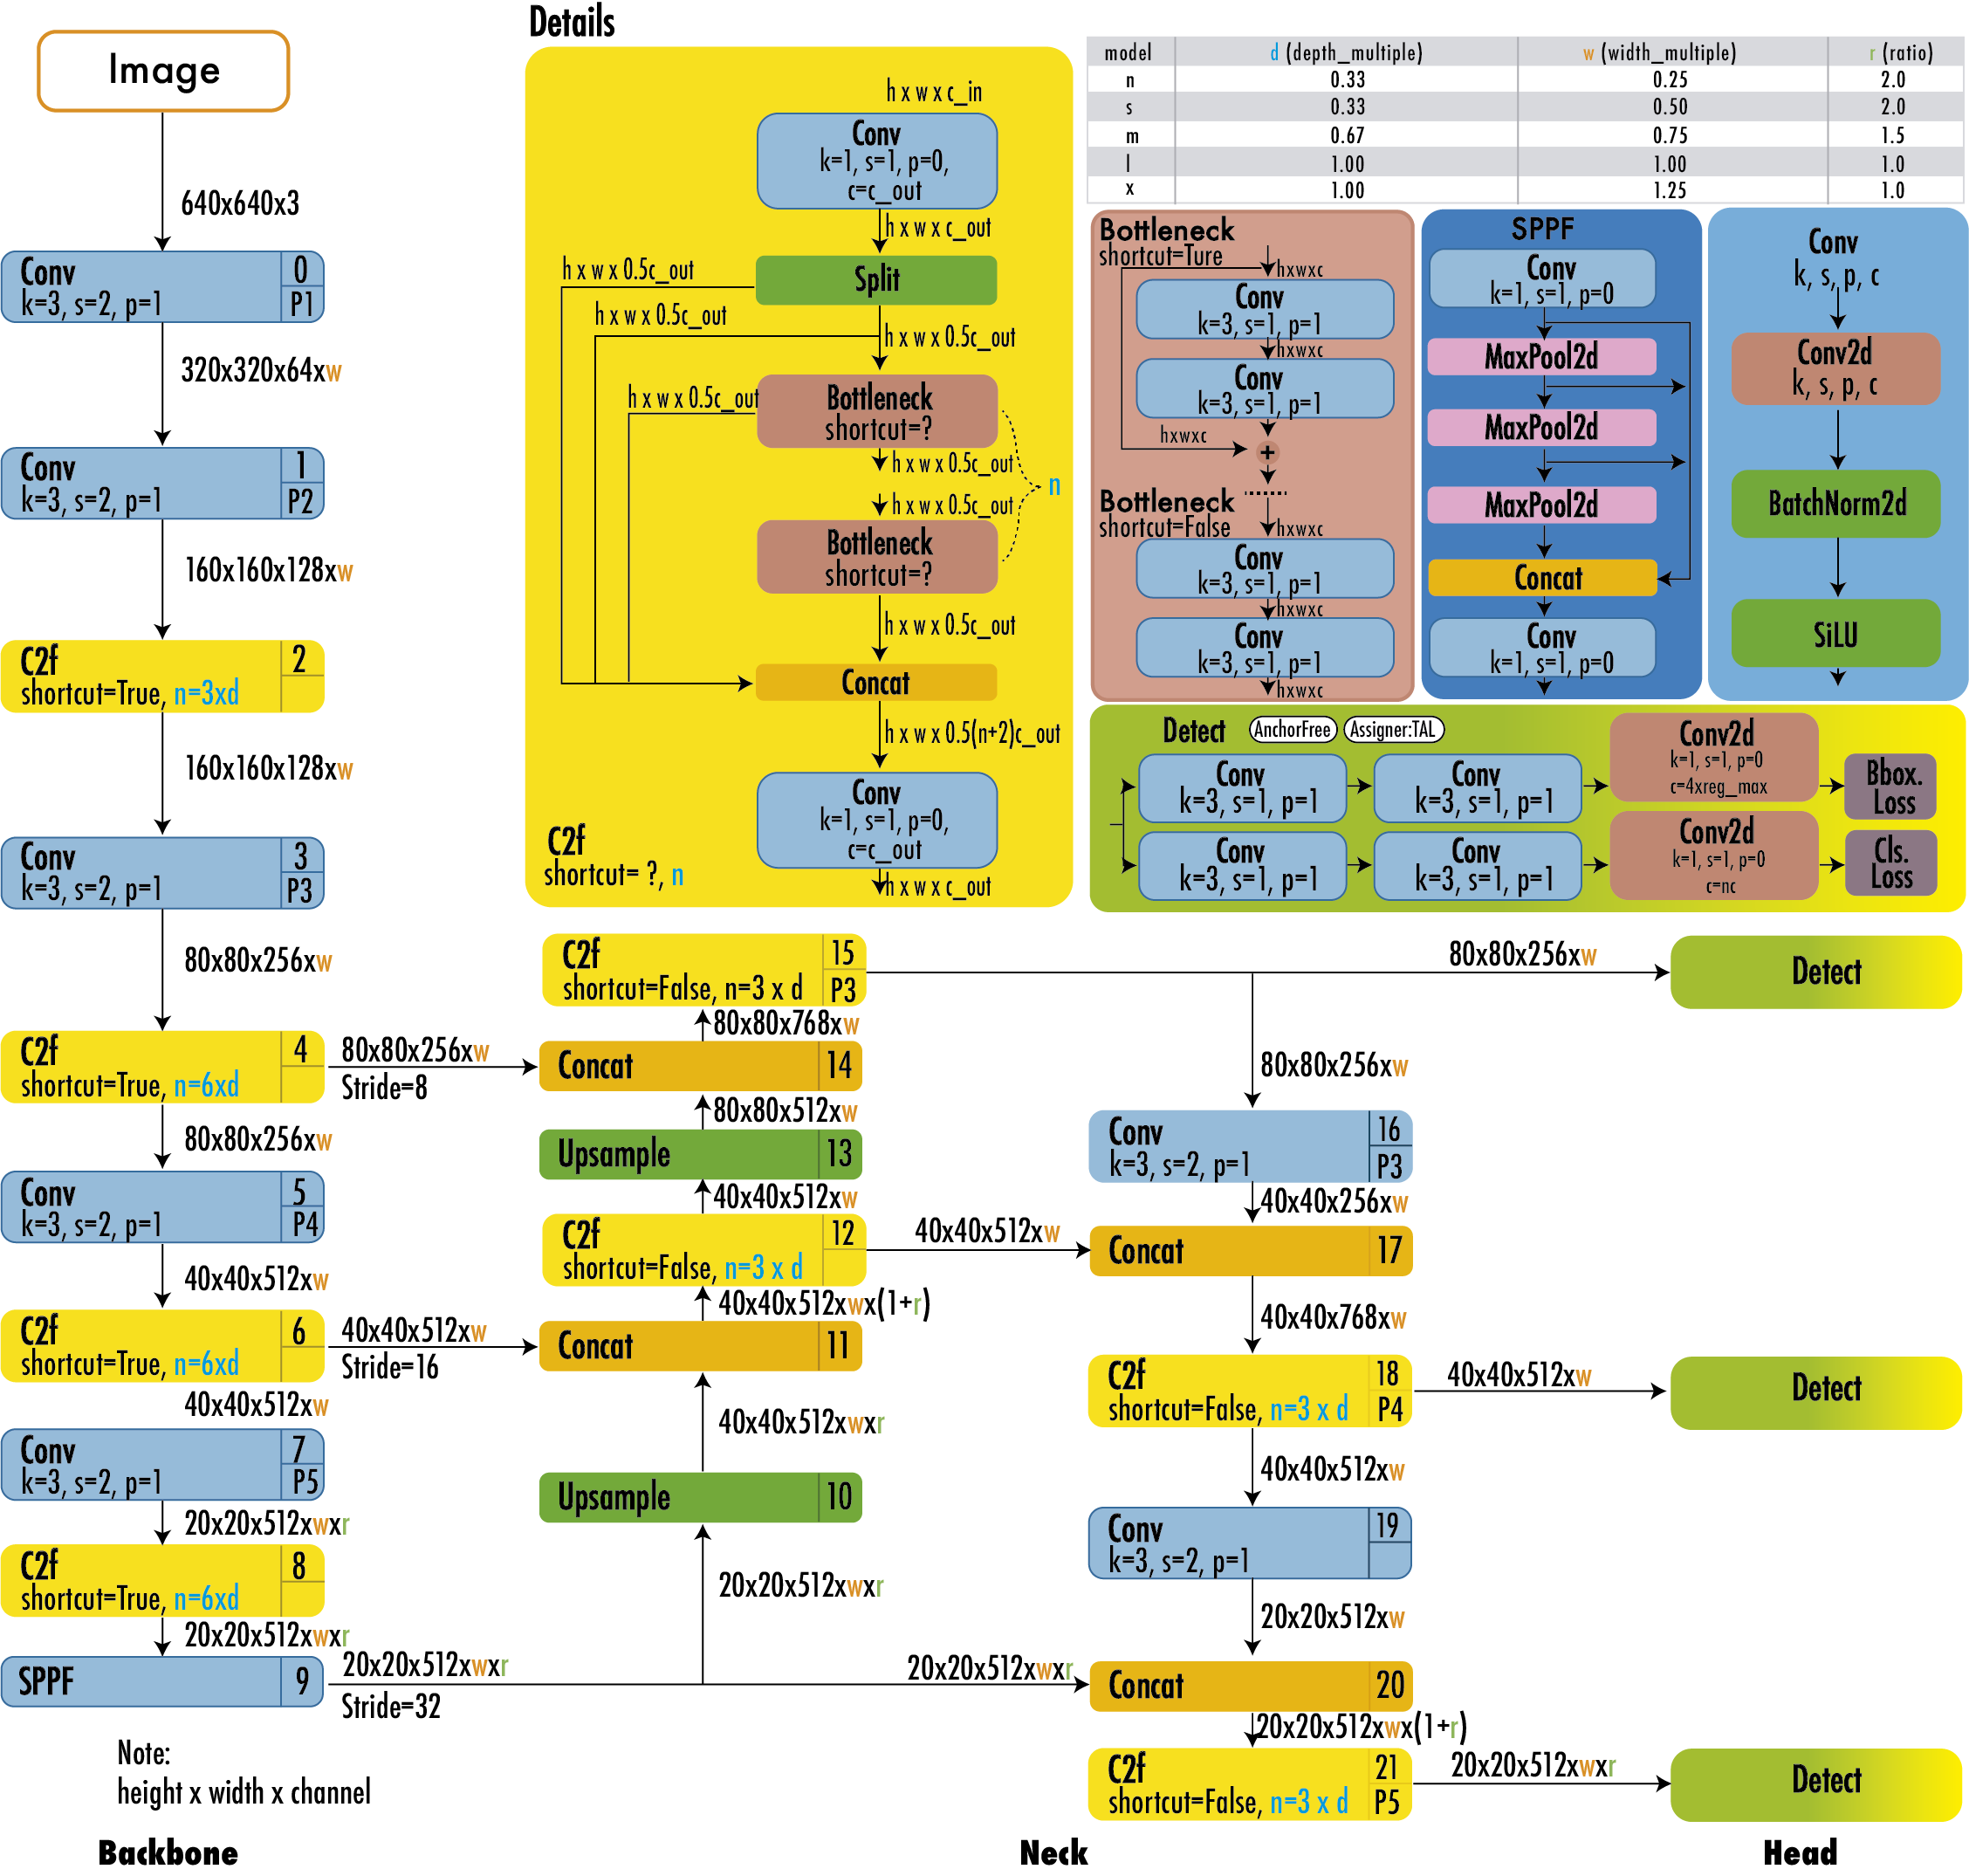

# 1 Backbone
The backbone is modified CSPDarknet23 which comprises of blocks Conv,C2f,SPPF

1. __Conv__ : Conv2d + BatchNorm2s+SiLU
2. __C2F(cross-stage partial bottlneck with 2 convolutions)__:Conv+Bottlenecks+Conv
   Combine high-level features with contextual information to improve detection accuracy.

3. __SPPF(spatial pyramid pooling fast):__ Conv+Maxpool2d+Conv
   Process features at various scales and pool them into a fixed-size feature map.

In [5]:
import torch
import torch.nn as nn


##


## Conv

In [16]:


class Conv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, activation=True, groups=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False, groups=groups)
        self.bn = nn.BatchNorm2d(out_channels, eps=0.001, momentum=0.03)
        self.act = nn.SiLU(inplace=True) if activation else nn.Identity()

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))


## C2f

In [28]:
# 2.1 Bottleneck: staack of 2 COnv with shortcut connection (True/False) 

class Bottleneck(nn.Module):
    def __init__(self, in_channels, out_channels, shortcut=True):
        super().__init__()
        self.conv1 = Conv(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.conv2 = Conv(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.shortcut = shortcut and in_channels == out_channels  # residual only if same channels

    def forward(self, x):
        x_in = x    # for residual connection 
        x = self.conv1(x)
        x = self.conv2(x)
        if self.shortcut:
            x = x + x_in
        return x



# 2.2 C2f: Conv + bottleneck*N+ Conv

class C2f(nn.Module):
    def __init__(self, in_channels, out_channels, num_bottlenecks=1, shortcut=True):
        super().__init__()
        self.num_bottlenecks = num_bottlenecks
        self.mid_channels = out_channels // 2

        self.conv1 = Conv(in_channels, out_channels, kernel_size=1, padding=0)

        self.m = nn.ModuleList([
            Bottleneck(self.mid_channels, self.mid_channels, shortcut=shortcut)
            for _ in range(num_bottlenecks)
        ])

        self.conv2 = Conv((num_bottlenecks + 2) * self.mid_channels, out_channels, kernel_size=1, padding=0)

    def forward(self, x):
        x = self.conv1(x)
        # Split along channel dim
        x1, x2 = x.split(self.mid_channels, dim=1)
        outputs = [x1, x2]

        for i in range(self.num_bottlenecks):
            x1 = self.m[i](x1)
            outputs.append(x1)

        x = torch.cat(outputs, dim=1)
        return self.conv2(x)


# sanity check 

c2f = C2f(in_channels= 64,out_channels = 128,num_bottlenecks = 2)
print(f"{sum(p.numel() for p in c2f.parameters())/1e6}million parameters")

dummy_input = torch.rand((1,64,244,244))
dummy_input = c2f(dummy_input)
print("Output shape: ",dummy_input.shape)
    

0.18944million parameters
Output shape:  torch.Size([1, 128, 244, 244])


## SPPF

In [32]:
class SPPF(nn.Module): 
    def __init__(self, in_channels, out_channels, kernel_size=5):
        super().__init__()
        hidden_channels = in_channels // 2
        self.conv1 = Conv(in_channels, hidden_channels, kernel_size=1, stride=1, padding=0)
        self.m = nn.MaxPool2d(kernel_size=kernel_size, stride=1, padding=kernel_size // 2)
        self.conv2 = Conv(4 * hidden_channels, out_channels, kernel_size=1, stride=1, padding=0)

    def forward(self, x): 
        x = self.conv1(x)
        y1 = self.m(x)
        y2 = self.m(y1)
        y3 = self.m(y2)
        y = torch.cat([x, y1, y2, y3], dim=1)
        return self.conv2(y)

# Sanity check
sppf = SPPF(in_channels=128, out_channels=512)
print(f"{sum(p.numel() for p in sppf.parameters()) / 1e6} million parameters")

dummy_input = torch.randn(1, 128, 64, 64)
dummy_output = sppf(dummy_input)
print("Output shape:", dummy_output.shape)

0.140416 million parameters
Output shape: torch.Size([1, 512, 64, 64])


In [85]:
# backbone  = DarkNet53

# return d, w, r based on version 
def yolo_params(version):
    if version == 'n':
        return 1/2, 1/4, 2.0
    elif version == 's':
        return 1/3, 1/2, 2.0
    elif version == 'm':
        return 2/3, 3/4, 1.5
    elif version == 'l':
        return 1.0, 1.0, 1.0
    elif version == 'x': 
        return 1.0, 1.25, 1.0

class Backbone(nn.Module):
    def __init__(self, version, in_channels=3, shortcut=True):
        super().__init__()
        d, w, r = yolo_params(version)

        self.conv_0 = Conv(in_channels, int(64 * w), kernel_size=3, stride=2, padding=1)
        self.conv_1 = Conv(int(64 * w), int(128 * w), kernel_size=3, stride=2, padding=1)
        self.conv_3 = Conv(int(128 * w), int(256 * w), kernel_size=3, stride=2, padding=1)
        self.conv_5 = Conv(int(256 * w), int(512 * w), kernel_size=3, stride=2, padding=1)
        self.conv_7 = Conv(int(512 * w), int(512 * w * r), kernel_size=3, stride=2, padding=1)

        # C2f layers
        self.c2f_2 = C2f(int(128 * w), int(128 * w), num_bottlenecks=int(3 * d), shortcut=True)
        self.c2f_4 = C2f(int(256 * w), int(256 * w), num_bottlenecks=int(6 * d), shortcut=True)
        self.c2f_6 = C2f(int(512 * w), int(512 * w), num_bottlenecks=int(6 * d), shortcut=True)
        self.c2f_8 = C2f(int(512 * w * r), int(512 * w * r), num_bottlenecks=int(6 * d), shortcut=True)

        self.sppf = SPPF(int(512 * w * r), int(512 * w * r))

    def forward(self, x):
        x = self.conv_0(x)
        x = self.conv_1(x)
        x = self.c2f_2(x)
        x = self.conv_3(x)
        out1 = self.c2f_4(x)  # Keep for output

        x = self.conv_5(out1)
        out2 = self.c2f_6(x)  # Keep for output

        x = self.conv_7(out2)
        x = self.c2f_8(x)
        out3 = self.sppf(x)  # Final output

        return out1, out2, out3


# --- Run model parameter count ---
print("--Nano model--")
backbone_n = Backbone(version='n')
print(f"{sum(p.numel() for p in backbone_n.parameters()) / 1e6} million parameters")

print("--Small Model--")
backbone_s = Backbone(version='s')
print(f"{sum(p.numel() for p in backbone_s.parameters()) / 1e6} million parameters")


--Nano model--
2.031824 million parameters
--Small Model--
6.391456 million parameters


In [86]:
# sanity check 

x = torch.rand(1,3,640,640)
out1,out2,out3 = backbone_n(x)
print(out1.shape)
print(out2.shape)
print(out3.shape)


torch.Size([1, 64, 80, 80])
torch.Size([1, 128, 40, 40])
torch.Size([1, 256, 20, 20])


## Neck 

The neck comprises of Upsample + C2f with 

__Upsample__=nearest-neighbor interpolation with scale_factor = 2. It doesn't have trainable parameters.

# upsample = nearest-neighbor interpolation with scale_factor =2 

#             doesn't have trainable parameters 



In [49]:
class Upsample(nn.Module): 
    def __init__(self,scale_factor = 2,mode = 'nearest'):
        super().__init__()
        self.scale_factor = scale_factor
        self.mode = mode

    def forward(self,x):
        return nn.functional.interpolate(x,scale_factor = self.scale_factor,mode = self.mode)
        

In [61]:
class Neck(nn.Module):
    def __init__(self,version):
        super().__init__()
        d,w,r = yolo_params(version)
        self.up = Upsample() #no trainable parameters 

        self.c2f_1=C2f(in_channels =int(512*w*(1+r)),out_channels = int(512*w),num_bottlenecks= int (3*d), shortcut = False)
        self.c2f_2=C2f(in_channels =int(768*w),out_channels = int(256*w),num_bottlenecks= int (3*d), shortcut = False)
        self.c2f_3=C2f(in_channels =int(768*w),out_channels = int(512*w),num_bottlenecks= int (3*d), shortcut = False)
        self.c2f_4=C2f(in_channels =int(512*w*(1+r)),out_channels = int(512*w*r),num_bottlenecks= int (3*d), shortcut = False)

        self.cv_1 = Conv(in_channels=int(256*w),out_channels = int(256*w),kernel_size = 3, stride = 2, padding =1)
        self.cv_2 = Conv(in_channels=int(512*w),out_channels = int(512*w),kernel_size = 3, stride = 2, padding =1)


    def forward(self,x_res_1,x_res_2,x):
        # x_res_1,x_res_2,x = output of backbone

        res_1 = x #for residual connection 

        x = self.up(x)

        x = torch.cat([x,x_res_2],dim =1)

        res_2 = self.c2f_1(x) # for residual collection 

        x = self.up(res_2)
        x= torch.cat([x,x_res_1],dim =1) 

        out_1 = self.c2f_2(x)

        x = self.cv_1(out_1)

        x = torch.cat([x,res_2],dim=1)
        out_2 = self.c2f_3(x)

        x= self.cv_2(out_2)
        x = torch.cat([x,res_1],dim =1 ) 
        out_3 = self.c2f_4(x)

        return out_1,out_2,out_3


# sanity check 

neck = Neck(version = 'n')

print(f'{sum(p.numel() for p in neck.parameters())/1e6} million parameters')

x = torch.rand((1,3,640,640))
out1,out2,out3 = Backbone(version = 'n')(x)
out_1,out_2,out_3 = neck (out1,out2,out3)

print(out_1.shape)
print(out_2.shape)
print(out_3.shape)

        
        
        

0.98688 million parameters
torch.Size([1, 64, 80, 80])
torch.Size([1, 128, 40, 40])
torch.Size([1, 256, 20, 20])


## Head

Consist of 3 modules:

(1) bbox cordinates,

(2) classification scores,

(3) distribution focal loss(DFL).

__DFL__ consist the predicated bbox coordinates as a probabilty distribution. At interference time, it samples from the distribution to get refined coordinates(x,y,w,h). For example, to predict coordinate x in the normalized range [0,1]:

  1) DFL uses 16 bins which are equally spaced in [0,1], bin length = 1/16.
  2) The model outputs 16 numbers which corresponds to probabilities that x fails in these bins,for example,[0,0,.....9/10,1/10].
  3) Prediction for x = mean value = 9/10 *15/16 +1/10 *1 = 0.94375

## 1) DFL

In [67]:
# DFL 
class DFL(nn.Module):
    def __init__(self, ch=16):
        super().__init__()

        self.ch = ch 
        self.conv = nn.Conv2d(in_channels=ch, out_channels=1, kernel_size=1, bias=False)
        self.conv.requires_grad_(False)  # Set weights to not require grad

        # Initialize conv weights with [0, 1, ..., ch-1]
        x = torch.arange(ch, dtype=torch.float).view(1, ch, 1, 1)
        self.conv.weight.data[:] = torch.nn.Parameter(x)

    def forward(self, x):
        # x must have num_channels = 4 * ch: x = [bs, 4*ch, c]
        b, c, a = x.shape   # c = 4 * ch
        x = x.view(b, 4, self.ch, a).transpose(1, 2)  # [bs, ch, 4, a]

        # Softmax on channel dimension to get distribution probabilities 
        x = x.softmax(1)      # [b, ch, 4, a]
        x = self.conv(x)      # [b, 1, 4, a]
        return x.view(b, 4, a)  # [b, 4, a]


# Sanity check
dummy_input = torch.rand((1, 64, 128))
dfl = DFL()
print(f"{sum(p.numel() for p in dfl.parameters())} parameters")
dummy_output = dfl(dummy_input)
print(dummy_output.shape)
print(dfl)


16 parameters
torch.Size([1, 4, 128])
DFL(
  (conv): Conv2d(16, 1, kernel_size=(1, 1), stride=(1, 1), bias=False)
)


In [79]:
## Head 

class Head(nn.Module):
    def __init__(self,version,ch=16,num_classes = 80):
        super().__init__()
        self.ch = ch                                 #dfl channels
        self.coordinates = self.ch*4                 # number of bounding box cordinates
        self.nc = num_classes                        # 80 for COCO
        self.no = self.coordinates+self.nc           # numbers of ouputs per anchor box
        self.stride = torch.zeros(3)                 # strides computed during build
        d,w,r = yolo_params(version = version)


        # for bounding boxes 

        self.box = nn.ModuleList([
            nn.Sequential(Conv(int(256*w),self.coordinates,kernel_size = 3, stride = 1, padding = 1),
                          Conv(self.coordinates,self.coordinates,kernel_size =3 , stride = 1, padding =1),
                          nn.Conv2d(self.coordinates,self.coordinates,kernel_size =1, stride =1)),
            
            nn.Sequential(Conv(int(512*w),self.coordinates,kernel_size = 3, stride = 1, padding = 1),
                          Conv(self.coordinates,self.coordinates,kernel_size =3 , stride = 1, padding =1),
                          nn.Conv2d(self.coordinates,self.coordinates,kernel_size =1, stride =1)),

            nn.Sequential(Conv(int(512*w*r),self.coordinates,kernel_size = 3, stride = 1, padding = 1),
                          Conv(self.coordinates,self.coordinates,kernel_size =3 , stride = 1, padding =1),
                          nn.Conv2d(self.coordinates,self.coordinates,kernel_size =1, stride =1))
        ])



        # For Classes

        self.cls = nn.ModuleList([
            nn.Sequential(Conv(int(256*w),self.nc,kernel_size = 3, stride = 1, padding = 1),
                          Conv(self.nc,self.nc,kernel_size =3 , stride = 1, padding =1),
                          nn.Conv2d(self.nc,self.nc,kernel_size =1, stride =1)),

            nn.Sequential(Conv(int(512*w),self.nc,kernel_size = 3, stride = 1, padding = 1),
                          Conv(self.nc,self.nc,kernel_size =3 , stride = 1, padding =1),
                          nn.Conv2d(self.nc,self.nc,kernel_size =1, stride =1)),
            
            nn.Sequential(Conv(int(512*w*r),self.nc,kernel_size = 3, stride = 1, padding = 1),
                          Conv(self.nc,self.nc,kernel_size =3 , stride = 1, padding =1),
                          nn.Conv2d(self.nc,self.nc,kernel_size =1, stride =1))
        ])


        #dfl 

        self.dlf = DFL()


    def forward(self,x):
        # x = output of Neck = list of 3 tensors with different resoultion and different channel dim 
        # x[0] = [bs,ch0,w0,h0],x[1]=[bs,ch1,w1,h1], x[2] = [bs,ch2,w2,h2]

        for i in range(len(self.box)):           # detection head i
            box = self.box[i](x[i])              # [bs,num_coordinates,w,h]
            cls = self.cls[i](x[i])              # [bs,num_classes,w,h]

            x[i]= torch.cat((box,cls),dim = 1)    # [bs,num_coordinates + num_classes,w,h]

            # in training, no dfl output

            if self.training: 
                return x        # [ 3,bs,num_coordinates+num_classes,w,h]


            # in inference time, dfl produces refined bounding box coordinates 

            anchors, strides = (i.transpose(0,1) for i in self.make_anchors(x,self.stride))

            # concatenate predictions from all detection layers 

            x = torch.cat([i.view(x[0].shape[0],self.no,-1) for i in x], dim = 2)  # [bs,4*self.ch + self.nc, sum_i(h[i]w[i])]

            #split out prediction for box and cls
            #          box = [bs,4*self.ch,sum_i(h[i]w[i])]
            #          cls = [bs,self.nc,sum_i(h[i]w[i])]

            box, cls = x.split(split_size = (4*self.ch,self.nc),dim=1)


            a,b = self.dfl(box).chunk(2,1)     # a = b= [bs,2*self.ch,sum_i(h[i]w[i])]
            a = anchors.unsqueeze(0) -a 
            b = anchors.unsqueeze(0) +b 

            box = torch.cat(tensors=((a+b)/2,b-a),dim=1)
            return torch.cat(tensors=(box*strides,cls.sigmoid()),dim =1)




    def make_anchors(x,strides,offset = 0.5):
        # x = list of feature maps: x = x[x[0],.....,x[N-1]], in our case N = num_detection_head =3
        #                           each having shape [bs,ch,w,h]
        #         each feature map x[i] gives output[i] = w*h anchor coordinates + w*h stride values
        # strides = list of stride values indicating how much 
        #           the spatial resoultion of the feature map is reduced compared to the original image


        assert x is not None
        anchor_tensor, stride_tensor = [],[]
        dtype,device = x[0].dtype,x[0].device

        for i, stride in enumerate(stride):
            _,_,h,w = x[i].shape
            sx = torch.arange(end =w,device = device, dtype = dtype)+offset # x coordinates of anchor centers 
            sy = torch.arange(end = h, device = device, dtype = dtype) + offset # y coordinates of anchor centers 
            anchor_tensor.append(torch.stack((sx,sy),-1).view(-1,2))
            stride_tensor.append(torch.full((h*w,1), stride,dtype = dtype, device =device))

        return torch.cat(anchor_tensor),torch.cat(stride_tensor)
        





            
        




In [80]:
detect = Head(version ='n')
print(f"{sum(p.numel() for p in detect.parameters())/1e6} million parameters")

#out_1,out_2,out_3 are output of the neck 

output = detect([out_1,out_2,out_3])
print(output[0].shape)
print(output[1].shape)
print(output[2].shape)

print(detect)

0.897664 million parameters
torch.Size([1, 144, 80, 80])
torch.Size([1, 128, 40, 40])
torch.Size([1, 256, 20, 20])
Head(
  (box): ModuleList(
    (0): Sequential(
      (0): Conv(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
    )
    (1): Sequential(
      (0): Conv(
        (conv): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
    

## After Whole Night of Suffering 

In [82]:
# Putting everything together

class MyYolo(nn.Module):
    def __init__(self,version):
        super().__init__()
        self.backbone = Backbone(version = version)
        self.neck = Neck(version = version)
        self.head = Head(version = version)

    def forward(self,x):
        x = self.backbone(x)                    # return out1,out2,out3
        x = self.neck(x[0],x[1],x[2])           # return out_1,out_2,out_3
        return self.head(list(x))



model = MyYolo(version = 'n')
print(f"{sum(p.numel() for p in model.parameters())/1e6} million parameters")
print(model)


3.916368 million parameters
MyYolo(
  (backbone): Backbone(
    (conv_0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (conv_1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (conv_3): Conv(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (conv_5): Conv(
      (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
     

## Dataset and Train 

Due to computation constraint, we will only overfit 1 batch of data from YOLO2017. The loss in yolov8 consists 

1) box_loss
2) classification_loss
3) dfl_loss


1) Box loss: on bounding box coordinates
2) Classification loss: on classification logits
3) DFL: itegrated in box loss


How DFL loss work? 


1. Target distribution = single value over 16 bins, this value will be smooth between 2 bin centers. For example, if target value is in the middle bin 1 and 2, target distribution = [1/2,1/2,0,.......,0]
2. Predicted distribution is based on the output of bbox coordinates. These outputs can be used to compute the probabilities for each bin , say [1/16,1/16,.....,1/16]
3. DFL = cross entropy between predication and target

The utils file for computing loss is taken from https://github.com/jahongir7174/YOLOv8-dfl/tree/master